In [93]:
using Distributed
np = length(Sys.cpu_info())
# addprocs(np - 2);
print(nprocs())


1

In [94]:
using PyPlot
using Profile, BenchmarkTools
using LaTeXStrings
using JLD2, FileIO

@everywhere include("../src/zp_simple_clifford.jl")

for i in 1:nprocs()
    s = rand(1:9999)
    @spawnat i Random.seed!(s)
end

PyPlot.rc("font", family="serif")
matplotlib.style.use("default")
rcParams = PyPlot.PyDict(PyPlot.matplotlib."rcParams")
rcParams["mathtext.fontset"] = "cm"
rcParams["mathtext.rm"] = "serif"

cmap = PyPlot.get_cmap("plasma")

cm = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", 
    "#e377c2", "#7f7f7f","#bcbd22", "#17becf", "b", "g", "r", "c", "m", "y", 
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", 
    "#e377c2", "#7f7f7f","#bcbd22", "#17becf", "b", "g", "r", "c", "m", "y"
];

In [95]:
@everywhere function rand_unit(T, k, b)
    n = k + b
    tmp = random_state(T, n)
#     check_xz(tmp.xz)
    tmp2 = tproduct([tmp, tmp])
#     check_xz(tmp2.xz)
    state = contract_sites!(tmp2, 1:k, n+1:n+k)
    tmpp = zeros(Int,2, b)
    tmpp[1:2:2b] .= 1:b
    tmpp[2:2:2b] .= (b+1:2b)
    state = reorder_sites(state, tmpp)
    @assert nsites(state)==2b
    return state
end


@everywhere function s2b(s)
    b = zeros(Int, 2*length(s))
    for i in 1:length(s)
        b[2i-1] = 2s[i]-1
        b[2i] = 2s[i]
    end
    return b
end




#####################################################################

@everywhere mutable struct StabTensor{T}
    state::StabState{T}
    B::Int
end
@everywhere copy(a::StabTensor{T}) where T  = StabTensor{T}(copy(a.state), a.B)
@everywhere nlegs(a::StabTensor)  = div(nsites(a.state), a.B)

@everywhere function rand_peps(T, k, B)
    @assert iseven(B)
    b = div(B, 2)
    state = rand_unit(T, k, 4b)
    tn = StabTensor{T}(state, B)
    @assert nlegs(tn)==4
    return tn
end

@everywhere function product_tn(n, B)
    state = all_up(T, n * B)
#     check_xz(state.xz)
    return StabTensor{T}(state, B)
end


@everywhere function bl2s(rg, B)
    tmp = zeros(Int, B, length(rg))
    for k in 1:B
        tmp[k, :] .= B .* (rg .- 1) .+ k
    end
    return reshape(tmp, length(tmp))
end

@everywhere function tproduct(tns::Vector{StabTensor{T}}) where T
    states = [t.state for t in tns]
    state = tproduct(states)
    return StabTensor{T}(state, tns[1].B)
end

@everywhere function measure_out!(tn::StabTensor, Is)
    B = tn.B
    inds = cat([bl2s(I, B) for I in Is]..., dims=1)
    state = tn.state
    state = measure_out!(state, inds)
    return StabTensor{T}(state, B)
end

@everywhere function contract_legs!(tn::StabTensor, Is, Js)
    B = tn.B
    @assert length(Is) == length(Js)
    inds = cat([bl2s(I, B) for I in Is]..., dims=1)
    jnds = cat([bl2s(J, B) for J in Js]..., dims=1)
    state = tn.state
    state = contract_sites!(state, inds, jnds)
    return StabTensor{T}(state, B)
end

@everywhere function hstack(tns, obc)
    m = length(tns)
    Is = Int[]
    Js = Int[]
    s = 0
#     [check_xz(tn.state.xz) for tn in tns]
    for i in 1:m
        n = nlegs(tns[i])
        (i > 1) && push!(Is, s+1)
        (i < m) && push!(Js, s+n)
        s += n
    end
    tn = tproduct(tns)
    tn = contract_legs!(tn, Is, Js)
    if obc
        tn = measure_out!(tn, [1, nlegs(tn)])
    else
        tn = contract_legs!(tn, [1], [nlegs(tn)])
    end
    return tn
end

@everywhere function tn_on_tn(tn1, tn2)
#     check_xz(tn1.state.xz)
#     check_xz(tn2.state.xz)
    n1 = nlegs(tn1)
    n2 = nlegs(tn2)
    @assert n1 % n2 == 0
    Is = 2:2:n1
    Js = n1 .+ (1:n2)
    tn = tproduct([tn1, tn2])
    tn = contract_legs!(tn, Is, Js)
    return tn
end

@everywhere function rand_layer(T, k, B, n, obc)
    tns = [rand_peps(T, k, B) for _ in 1:n]
    return hstack(tns, obc)
end

@everywhere function const_layer(tn, n, obc)
    tns = [tn for _ in 1:n]
    return hstack(tns, obc)
end

@everywhere function ees(tn::StabTensor)
    B = tn.B
    tmp = ee_on_all_cuts(tn.state)
    return tmp[B:B:end]
end

In [96]:
@everywhere function ee_rand_sim(T, n, B, k, n_step, step_size, n_avg, obc)
    result = zeros(n_step, n)
    for _ in 1:n_avg
        tn = product_tn(n, B)
        for i in 1:n_step
            result[i, :] += ees(tn)
            for _ in 1:step_size
                tnn = rand_layer(T, k, B, n, obc)
                tn = tn_on_tn(tnn, tn)
            end
        end
    end
    return result ./ n_avg
end

@everywhere function ee_const_sim(n, B, k, n_step, step_size, obc, unit)
    result = zeros(n_step, n)
    tnn = const_layer(unit, n, obc)
    tn = product_tn(n, B)
    for i in 1:n_step
        result[i, :] += ees(tn)
        for _ in 1:step_size
            tn = tn_on_tn(tnn, tn)
        end
    end
    return result
end


function alternation(mat)
    tmp = zeros(size(mat, 1), div(size(mat, 2),2))
    for i in 1:size(mat, 1)
        if iseven(i)
            tmp[i,:] = mat[i, 1:2:end]
        else
            tmp[i,:] = mat[i, 2:2:end]
        end
    end
    return tmp
end

alternation (generic function with 1 method)

In [ ]:
T = Zp{3}
n = 10
B = 2
k = 1

n_step = 4
step_size = 1
n_avg = 1
obc = false
nn = 30

h_list = []

@time begin
    result = [ee_rand_sim(T, n, 2B, k, n_step, step_size, n_avg, obc) for _ in 1:nn]
    result = mean(fetch(h) for h in result)
end

matshow(result)

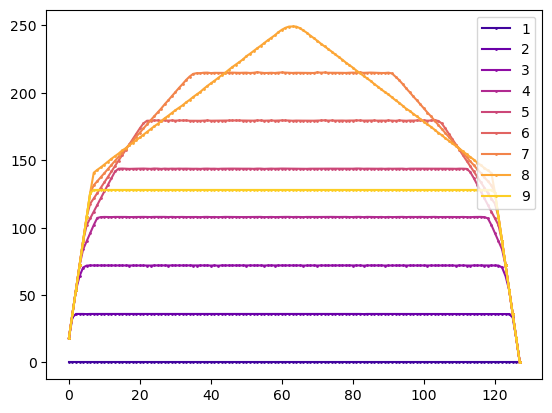

PyObject <matplotlib.legend.Legend object at 0x2b3825261050>

In [64]:
for i in 1:n_step
    plot(result[i, :], "-o", label=i, c=cmap(0.1*i), ms=1)
end
legend()

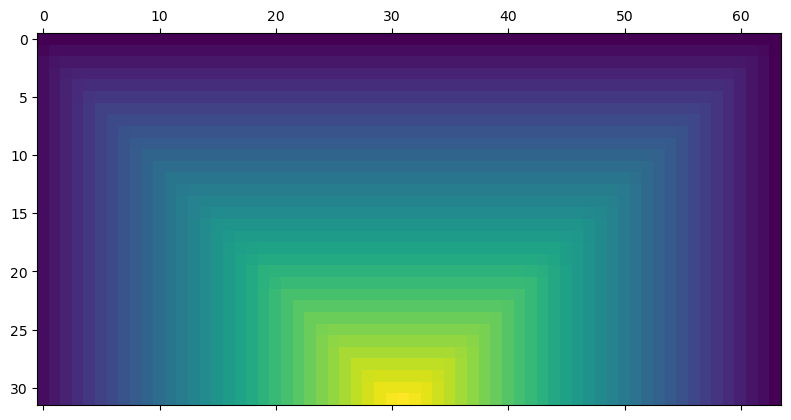

In [46]:
n = 64
B = 4
k = 0
n_step = 32
step_size = 1
obc = true

for s in 1:1
    Random.seed!(s)
    tn = rand_peps(k, 2B)
    result = ee_const_sim(n, 2B, k, n_step, step_size, obc, tn)
    matshow(result)
end

In [ ]:
n = 64
B_list = 1:16
k_list = 1:2
n_step = 20
step_size = 1
n_avg = 1
obc = false
nn = 30

@time begin
    result = zeros(length(B_list), length(k_list), n_step, n)
    for (i, B) in enumerate(B_list)
        for (j, k) in enumerate(k_list)
            tmp = [@spawn ee_rand_sim(n, 2B, k, n_step, step_size, n_avg, obc) for _ in 1:nn]    
            result[i,j,:,:] .= mean([fetch(h) for h in tmp])
        end
    end
    @save "./cache/221201_0vqzx" result
end



signal (15): Terminated
in expression starting at In[12]:10
epoll_wait at /lib64/libc.so.6 (unknown line)
uv__io_poll at /workspace/srcdir/libuv/src/unix/epoll.c:240
uv_run at /workspace/srcdir/libuv/src/unix/core.c:383
jl_task_get_next at /buildworker/worker/package_linux64/build/src/partr.c:481
poptask at ./task.jl:827
wait at ./task.jl:836
wait at ./condition.jl:123
take_buffered at ./channels.jl:389
take! at ./channels.jl:383
_jl_invoke at /buildworker/worker/package_linux64/build/src/gf.c:2247 [inlined]
jl_apply_generic at /buildworker/worker/package_linux64/build/src/gf.c:2429
take! at /buildworker/worker/package_linux64/build/usr/share/julia/stdlib/v1.7/Distributed/src/remotecall.jl:730
#remotecall_fetch#155 at /buildworker/worker/package_linux64/build/usr/share/julia/stdlib/v1.7/Distributed/src/remotecall.jl:465
remotecall_fetch at /buildworker/worker/package_linux64/build/usr/share/julia/stdlib/v1.7/Distributed/src/remotecall.jl:461
unknown function (ip: 0x2adb14b36138)
#remo

Channel{Any}Worker 30 terminated.Unhandled Task ERROR: EOFError: read end of file
Stacktrace:
 [1] (::Base.var"#wait_locked#645")(s::Sockets.TCPSocket, buf::IOBuffer, nb::Int64)
   @ Base ./stream.jl:892
 [2] unsafe_read(s::Sockets.TCPSocket, p::Ptr{UInt8}, nb::UInt64)
   @ Base ./stream.jl:900
 [3] unsafe_read
   @ ./io.jl:724 [inlined]
 [4] unsafe_read(s::Sockets.TCPSocket, p::Base.RefValue{NTuple{4, Int64}}, n::Int64)
   @ Base ./io.jl:723
 [5] read!
   @ ./io.jl:725 [inlined]
 [6] deserialize_hdr_raw
   @ ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/messages.jl:167 [inlined]
 [7] message_handler_loop(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:165
 [8] process_tcp_streams(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:126
 [9] (::Distribu

Worker 7 terminated.Unhandled Task ERROR: EOFError: read end of file
Stacktrace:
 [1] (::Base.var"#wait_locked#645")(s::Sockets.TCPSocket, buf::IOBuffer, nb::Int64)
   @ Base ./stream.jl:892
 [2] unsafe_read(s::Sockets.TCPSocket, p::Ptr{UInt8}, nb::UInt64)
   @ Base ./stream.jl:900
 [3] unsafe_read
   @ ./io.jl:724 [inlined]
 [4] unsafe_read(s::Sockets.TCPSocket, p::Base.RefValue{NTuple{4, Int64}}, n::Int64)
   @ Base ./io.jl:723
 [5] read!
   @ ./io.jl:725 [inlined]
 [6] deserialize_hdr_raw
   @ ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/messages.jl:167 [inlined]
 [7] message_handler_loop(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:165
 [8] process_tcp_streams(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:126
 [9] (::Distributed.var"#99#1

Worker 11 terminated.Unhandled Task ERROR: EOFError: read end of file
Stacktrace:
 [1] (::Base.var"#wait_locked#645")(s::Sockets.TCPSocket, buf::IOBuffer, nb::Int64)
   @ Base ./stream.jl:892
 [2] unsafe_read(s::Sockets.TCPSocket, p::Ptr{UInt8}, nb::UInt64)
   @ Base ./stream.jl:900
 [3] unsafe_read
   @ ./io.jl:724 [inlined]
 [4] unsafe_read(s::Sockets.TCPSocket, p::Base.RefValue{NTuple{4, Int64}}, n::Int64)
   @ Base ./io.jl:723
 [5] read!
   @ ./io.jl:725 [inlined]
 [6] deserialize_hdr_raw
   @ ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/messages.jl:167 [inlined]
 [7] message_handler_loop(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:165
 [8] process_tcp_streams(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:126
 [9] (::Distributed.var"#99#

Worker 19 terminated.Unhandled Task ERROR: EOFError: read end of file
Stacktrace:
 [1] (::Base.var"#wait_locked#645")(s::Sockets.TCPSocket, buf::IOBuffer, nb::Int64)
   @ Base ./stream.jl:892
 [2] unsafe_read(s::Sockets.TCPSocket, p::Ptr{UInt8}, nb::UInt64)
   @ Base ./stream.jl:900
 [3] unsafe_read
   @ ./io.jl:724 [inlined]
 [4] unsafe_read(s::Sockets.TCPSocket, p::Base.RefValue{NTuple{4, Int64}}, n::Int64)
   @ Base ./io.jl:723
 [5] read!
   @ ./io.jl:725 [inlined]
 [6] deserialize_hdr_raw
   @ ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/messages.jl:167 [inlined]
 [7] message_handler_loop(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:165
 [8] process_tcp_streams(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:126
 [9] (::Distributed.var"#99#

Worker 27 terminated.Unhandled Task ERROR: EOFError: read end of file
Stacktrace:
 [1] (::Base.var"#wait_locked#645")(s::Sockets.TCPSocket, buf::IOBuffer, nb::Int64)
   @ Base ./stream.jl:892
 [2] unsafe_read(s::Sockets.TCPSocket, p::Ptr{UInt8}, nb::UInt64)
   @ Base ./stream.jl:900
 [3] unsafe_read
   @ ./io.jl:724 [inlined]
 [4] unsafe_read(s::Sockets.TCPSocket, p::Base.RefValue{NTuple{4, Int64}}, n::Int64)
   @ Base ./io.jl:723
 [5] read!
   @ ./io.jl:725 [inlined]
 [6] deserialize_hdr_raw
   @ ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/messages.jl:167 [inlined]
 [7] message_handler_loop(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:165
 [8] process_tcp_streams(r_stream::Sockets.TCPSocket, w_stream::Sockets.TCPSocket, incoming::Bool)
   @ Distributed ~/julia-1.7.2/share/julia/stdlib/v1.7/Distributed/src/process_messages.jl:126
 [9] (::Distributed.var"#99#

In [ ]:
n = 128
B_list = 1:9
k_list = 1:2
n_step = 10
step_size = 1
n_avg = 1
obc = false
nn = 30

@time begin
    result = zeros(length(B_list), length(k_list), n_step, n)
    for (i, B) in enumerate(B_list)
        for (j, k) in enumerate(k_list)
            tmp = [@spawn ee_rand_sim(n, 2B, k, n_step, step_size, n_avg, obc) for _ in 1:nn]    
            result[i,j,:,:] .= mean([fetch(h) for h in tmp])
        end
    end
    @save "./cache/221201_0bcdx" result
end



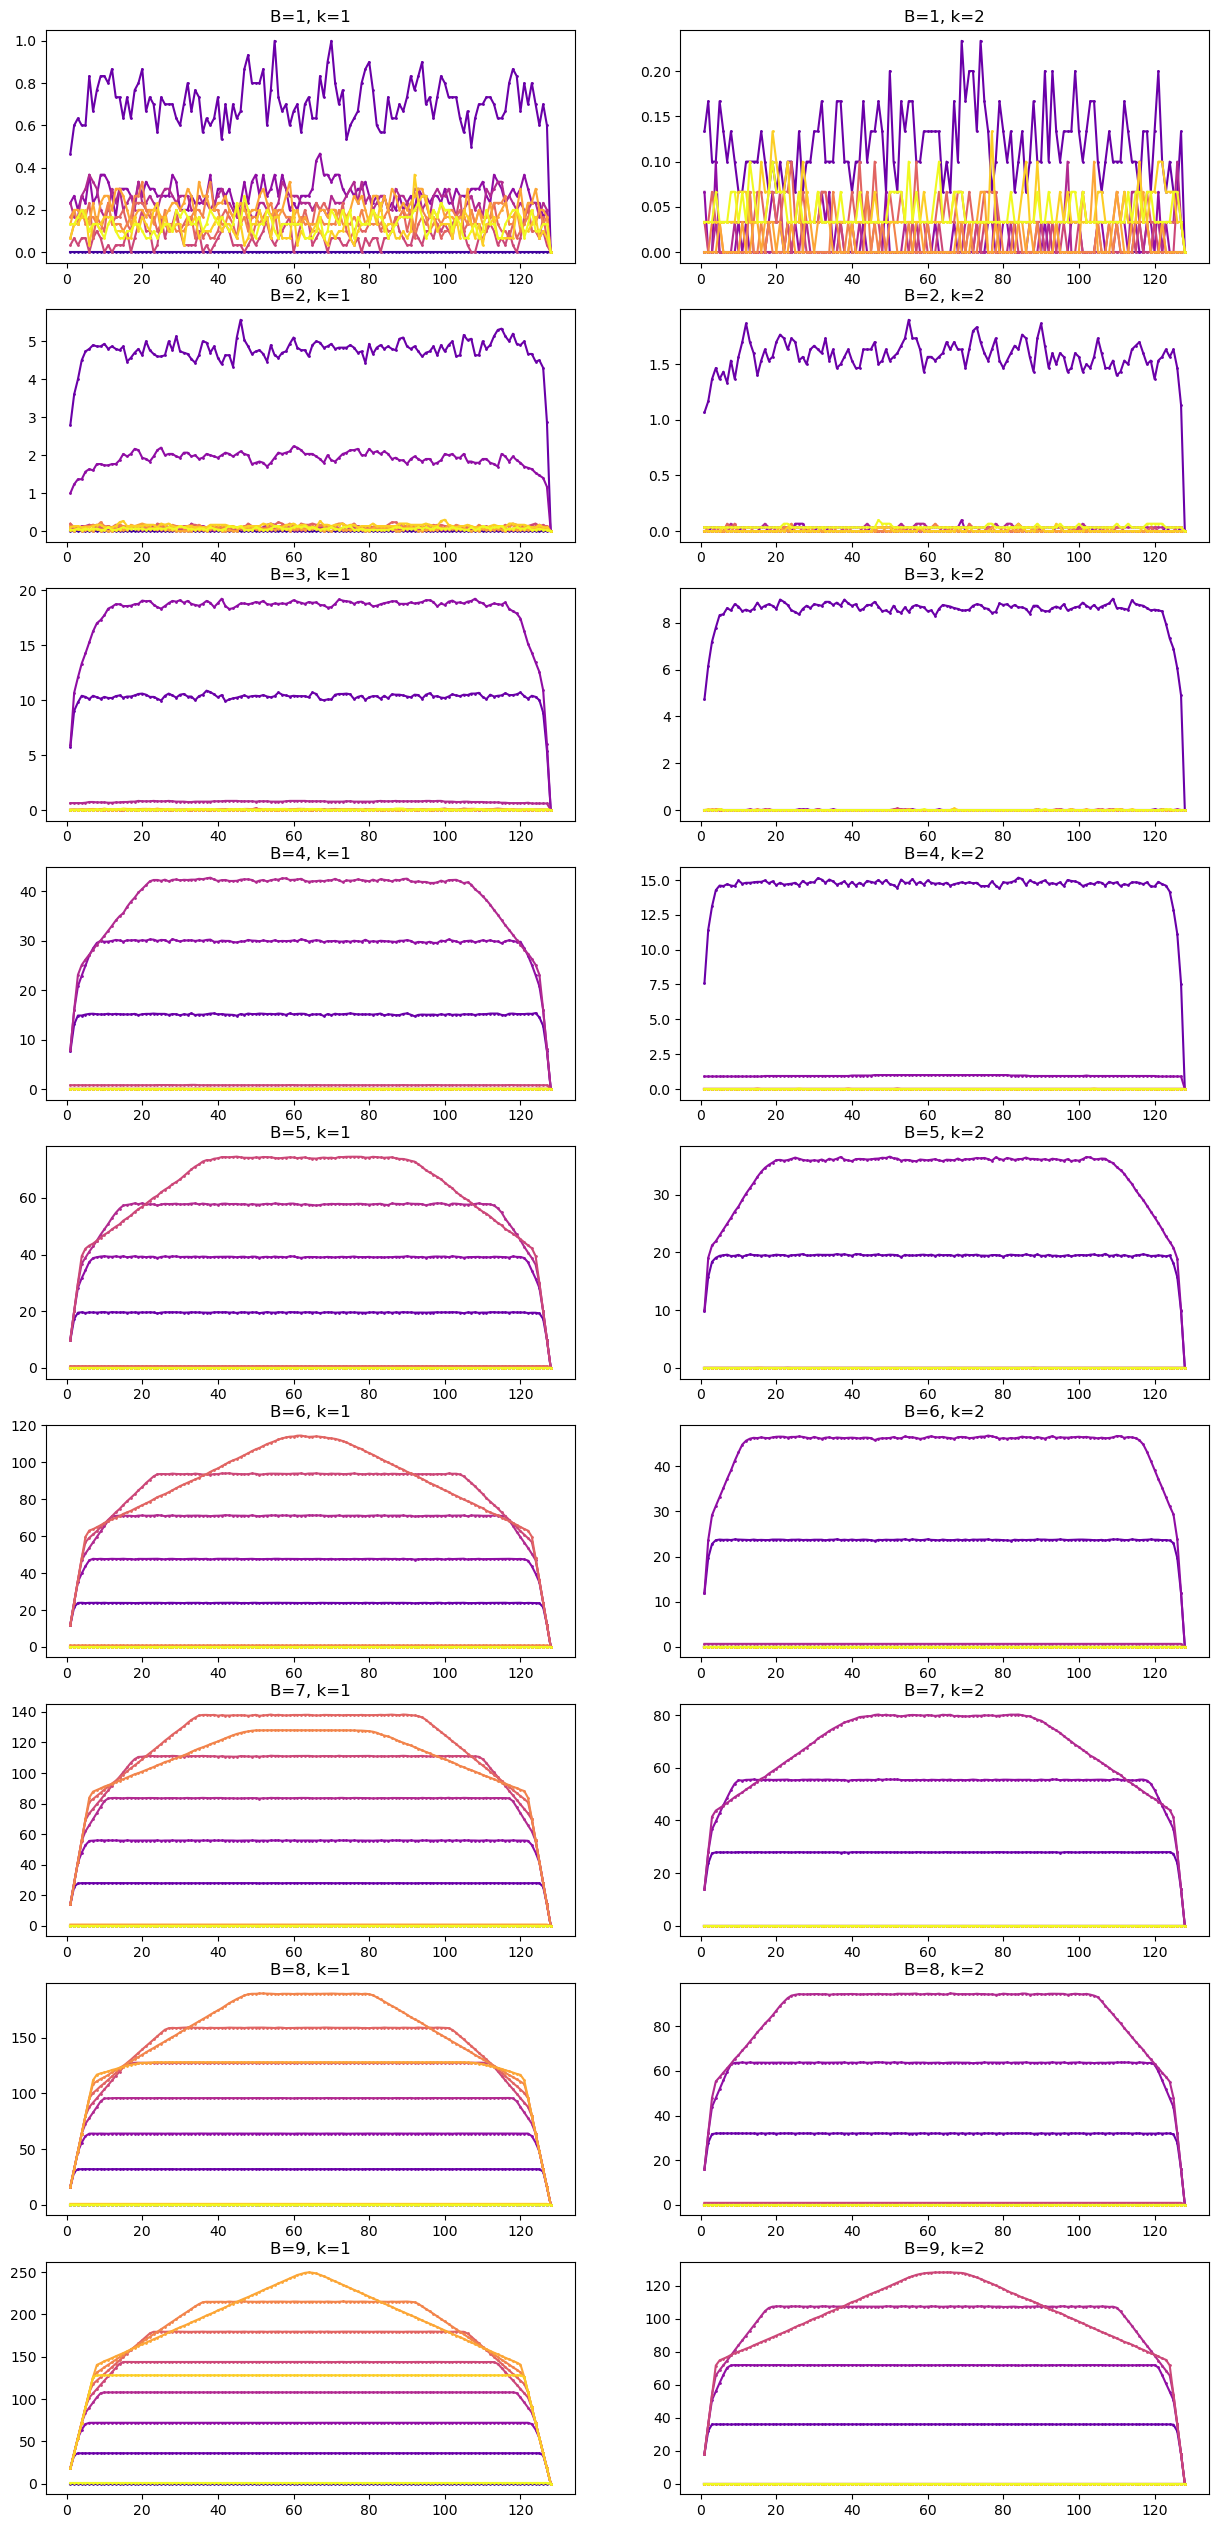

In [7]:
@load "./cache/221201_0bcdx" result

n = 128
B_list = 1:9
k_list = 1:2
n_step = 10
step_size = 1

mid = div(n, 2)
fg, axs = subplots(length(B_list), length(k_list), figsize=(15,32))

for i in 1:length(B_list)
    for j in 1:length(k_list)
        ax = axs[i,j]
        x = 1:n
        for t in 1:n_step
            y = result[i,j,t,:]
            ax.plot(x, y, "-o", ms=1, c=cmap(0.1t))
        end
        ax.set_title(string("B=", B_list[i], ", k=", k_list[j]))
    end
end

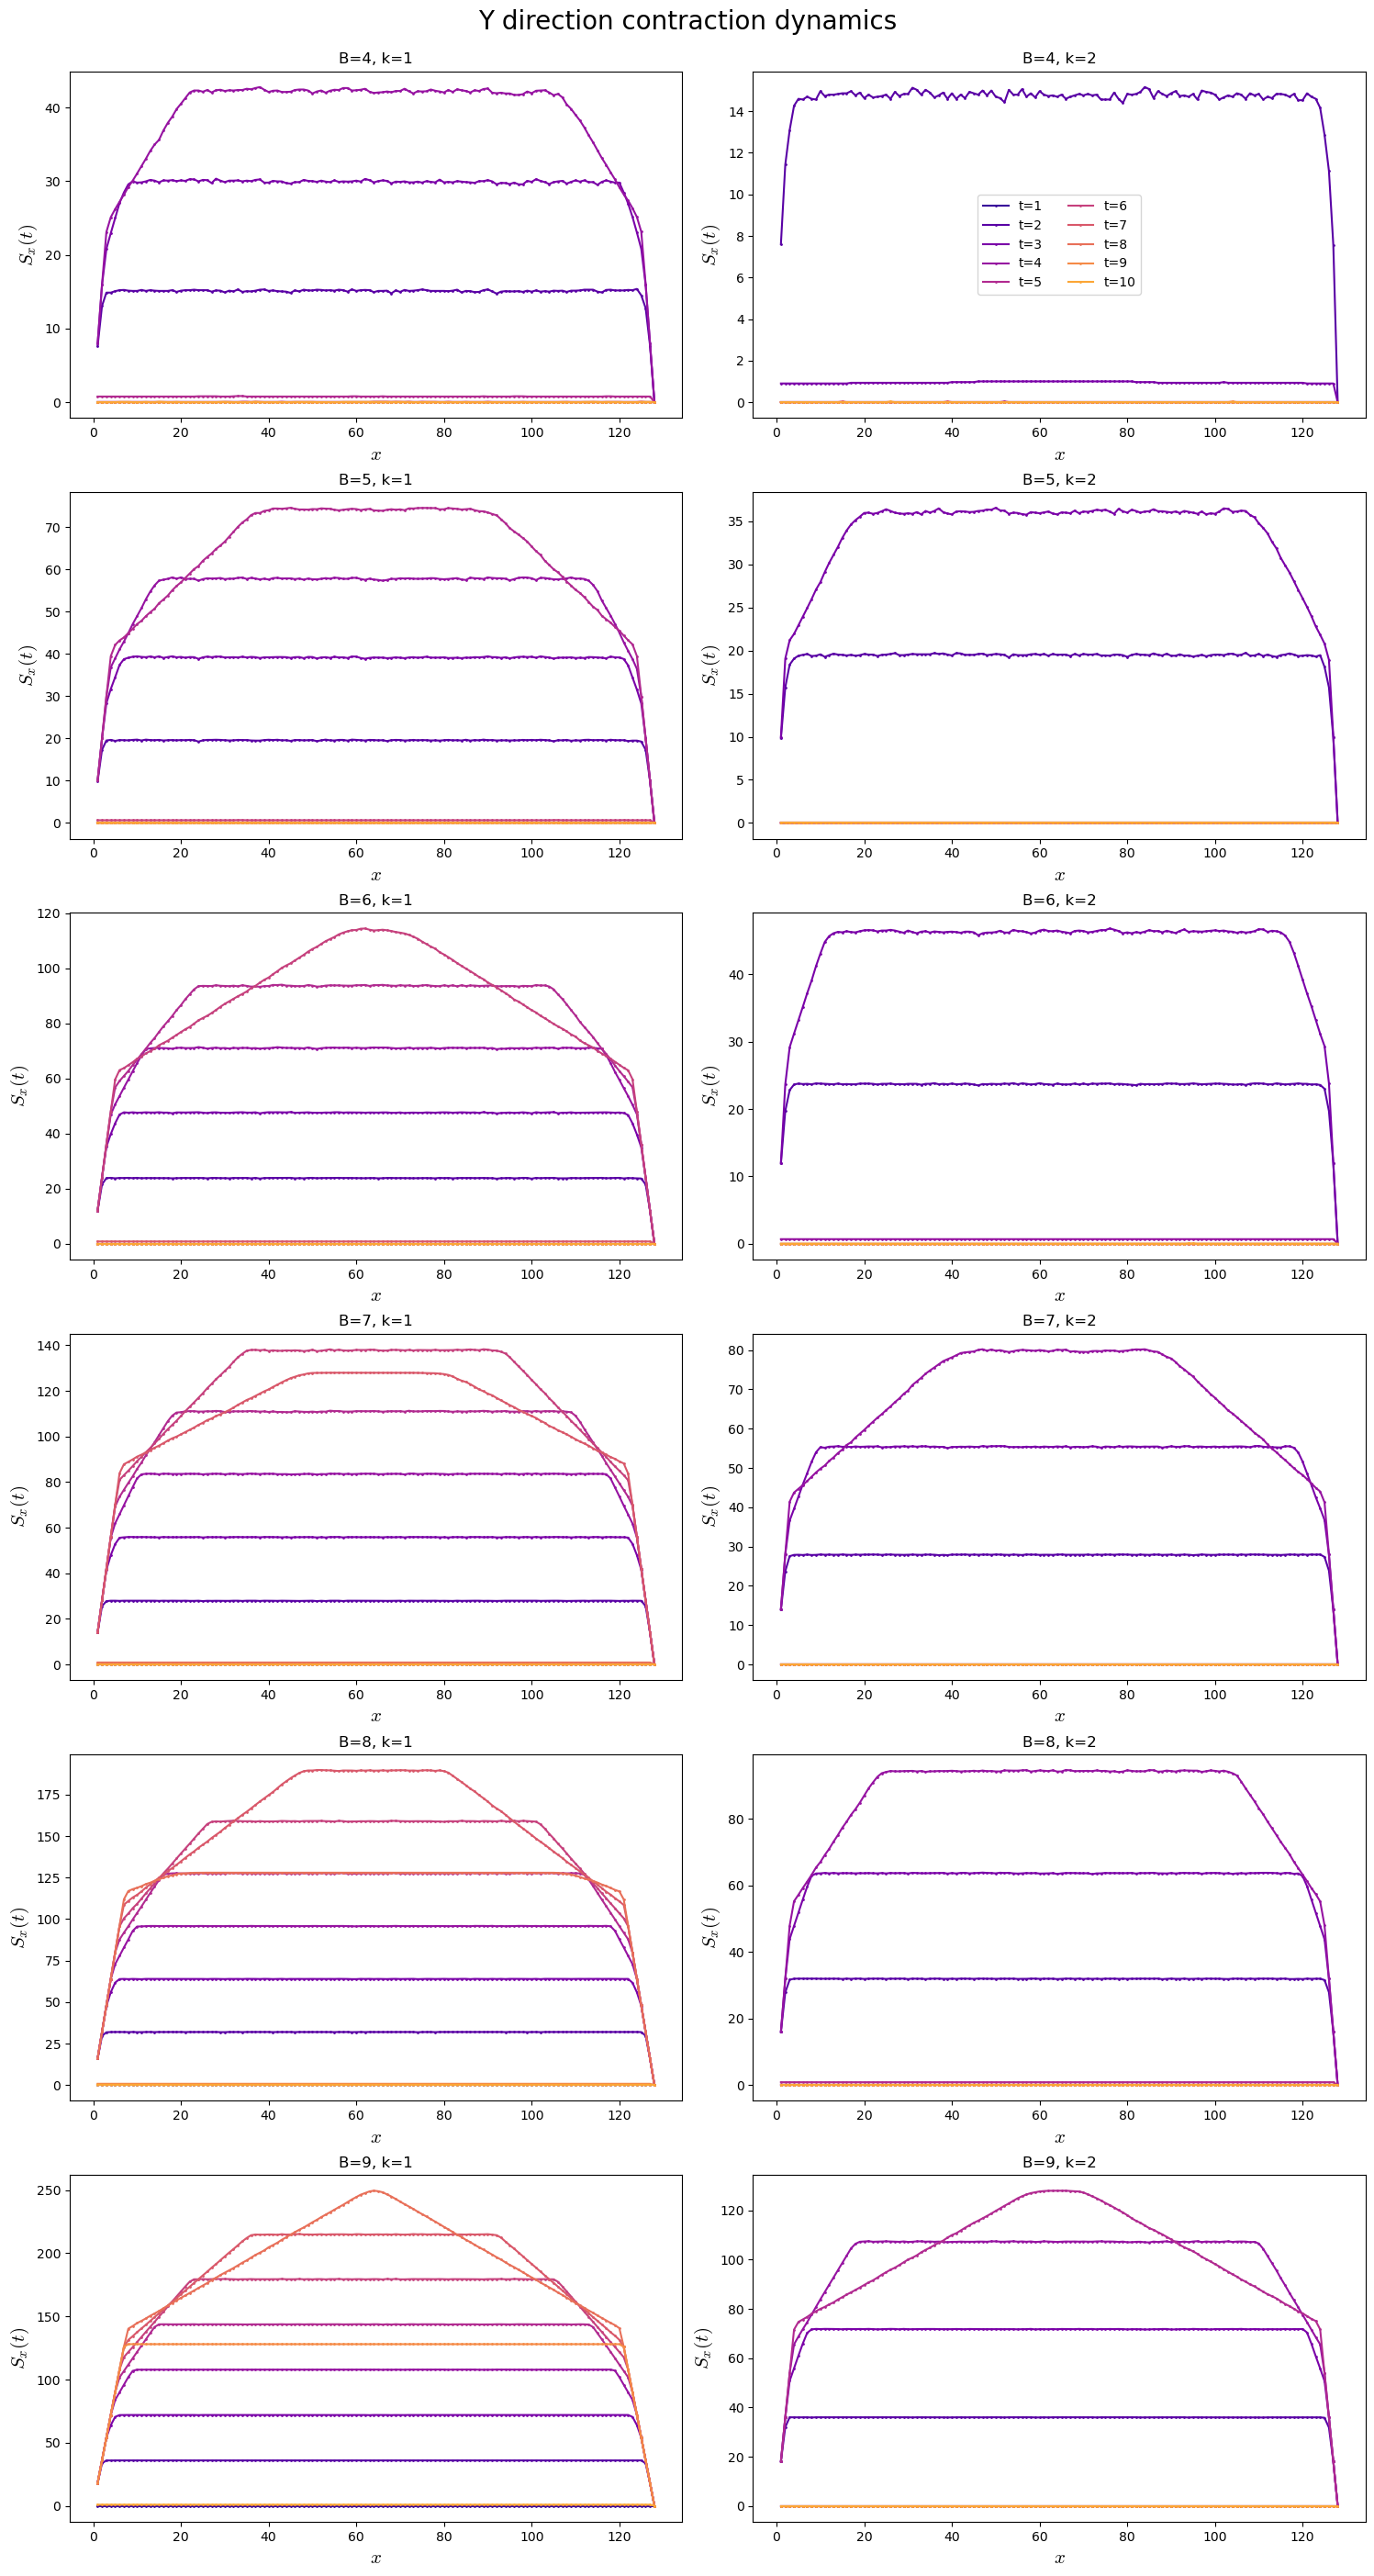

In [139]:
@load "./cache/221201_0bcdx" result

n = 128
B_list = 1:9
k_list = 1:2
n_step = 10
step_size = 1

mid = div(n, 2)
fg, axs = subplots(length(B_list)-3, length(k_list), figsize=(15,28))


for i in 1:length(B_list)
    B = B_list[i]
    if B < 4
        continue
    end
    for j in 1:length(k_list)
        ax = axs[B-3,j]
        x = 1:n
        for t in 1:n_step
            y = result[i,j,t,:]
            ax.plot(x, y, "-o", ms=1, c=cmap(0.08t), label="t=$t")
            
            ax.set_xlabel(L"x", fontsize=15)
            ax.set_ylabel(L"S_x(t)", fontsize=15)
            
        end
        ax.set_title(string("B=", B_list[i], ", k=", k_list[j]))
    end
end

axs[1, 2].legend(ncol=2)

fg.suptitle("Y direction contraction dynamics", y=.999, fontsize=20)

fg.tight_layout(pad=.8)
fg.savefig("./figure3.pdf")

x = B = 1
y = mean(result[i, j, end, :]) = 0.134375
x = B = 1
y = mean(result[i, j, end, :]) = 0.044270833333333315
x = B = 2
y = mean(result[i, j, end, :]) = 0.06848958333333331
x = B = 2
y = mean(result[i, j, end, :]) = 0.038020833333333316
x = B = 3
y = mean(result[i, j, end, :]) = 0.05104166666666665
x = B = 3
y = mean(result[i, j, end, :]) = 0.0015624999999999999
x = B = 4
y = mean(result[i, j, end, :]) = 0.007552083333333333
x = B = 4
y = mean(result[i, j, end, :]) = 0.00026041666666666666
x = B = 5
y = mean(result[i, j, end, :]) = 0.0005208333333333333
x = B = 5
y = mean(result[i, j, end, :]) = 0.0
x = B = 6
y = mean(result[i, j, end, :]) = 0.0
x = B = 6
y = mean(result[i, j, end, :]) = 0.0005208333333333333
x = B = 7
y = mean(result[i, j, end, :]) = 0.0
x = B = 7
y = mean(result[i, j, end, :]) = 0.0
x = B = 8
y = mean(result[i, j, end, :]) = 0.0
x = B = 8
y = mean(result[i, j, end, :]) = 0.0
x = B = 9
y = mean(result[i, j, end, :]) = 0.8929687500000006
x = B = 9
y = mean(result

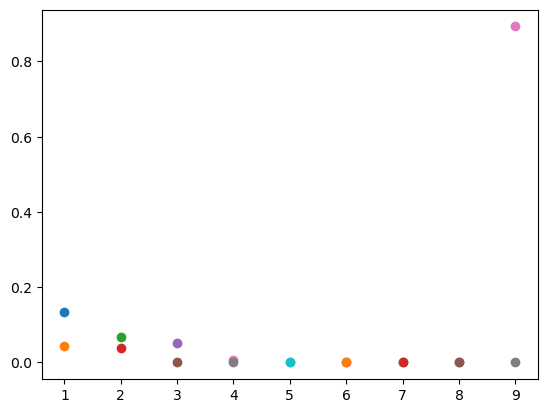

In [16]:
@load "./cache/221201_0bcdx" result

n = 128
B_list = 1:9
k_list = 1:2
n_step = 10
step_size = 1

mid = div(n, 2)


for i in 1:length(B_list)
    B = B_list[i]
    for j in 1:length(k_list)
        @show x = B
        @show y = mean(result[i,j,end,:])
        scatter([x],[y])
    end
end

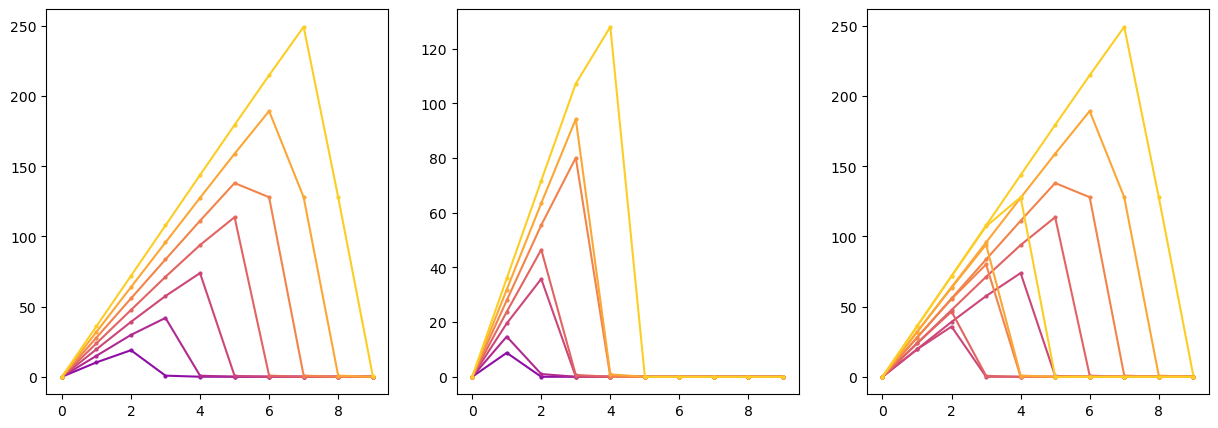

In [92]:
@load "./cache/221201_0bcdx" result

n = 128
B_list = 1:9
k_list = 1:2
n_step = 10
step_size = 1

mid = div(n, 2)
fg, axs = subplots(1,3, figsize=(15,5))




for j in 1:length(k_list)
    ax = axs[j]
    for i in 3:length(B_list)
        B = B_list[i]
        k = k_list[j]
        x = (0:n_step-1)
        y = result[i,j,:, mid] 
        ax.plot(x, y,"-o", ms=2, label=B,c=cmap(i*0.1))
    end
end


ax = axs[3]


for j in 1:length(k_list)
    for i in 5:length(B_list)
        B = B_list[i]
        k = k_list[j]
        x = (0:n_step-1)
        y = result[i,j,:, mid]
        ax.plot(x, y,"-o", ms=2, label=B,c=cmap(i*0.1))
    end
end

In [20]:
n = 64
B = 2
k = 1
n_step = 32
step_size = 1
n_avg = 1
obc = true
B_list = 1:3
k_list = 0:2

h_list = []

result = zeros(length(B_list), length(k_list), n_step, n)

for (i,B) in enumerate(B_list)
    for (j,k) in enumerate(k_list)
        result[i,j,:,:] = ee_rand_sim(n, 2B, k, n_step, step_size, n_avg, obc)
    end
end

@save "./cache/221201_9bx2s" result

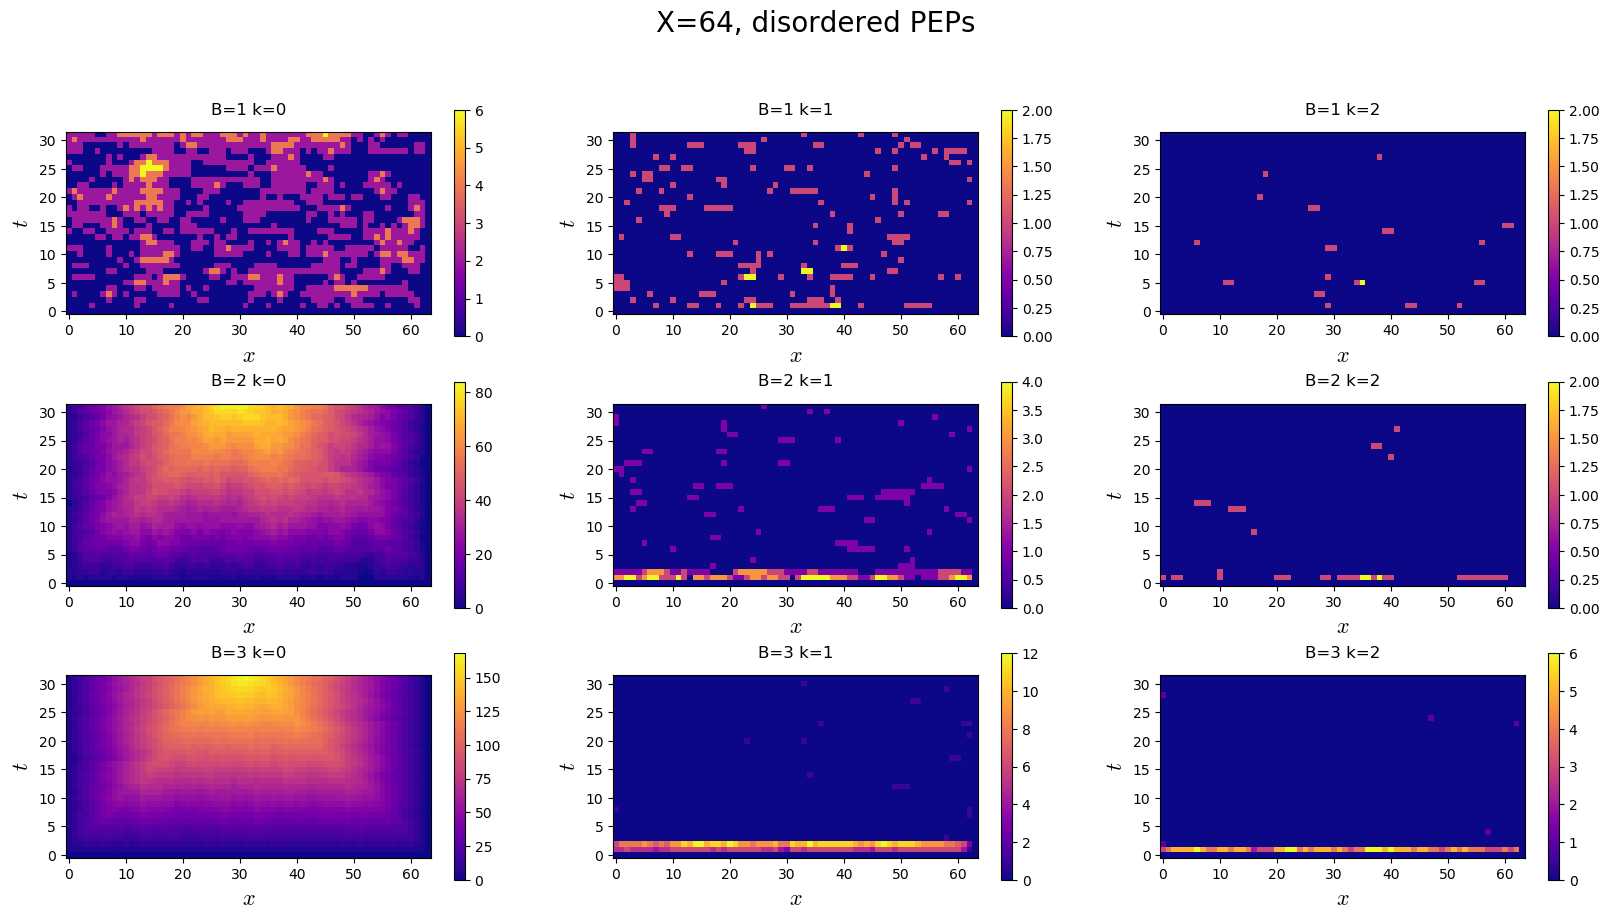

In [6]:
@load "./cache/221201_9bx2s" result

fg, axs = subplots(3,3,figsize=(20,10))

B_list = 1:3
k_list = 0:2


for (i,B) in enumerate(B_list)
    for (j,k) in enumerate(k_list)
        ax = axs[i,j]
        im = ax.matshow(result[i,j,:,:], cmap=cmap)
        ax.xaxis.set_ticks_position("bottom")
        ax.invert_yaxis()
        ax.set_xlabel(L"x",fontsize=16)
        ax.set_ylabel(L"t",fontsize=16)
        ax.set_title(string("B=", B, " k=", k))
        fg.colorbar(im,ax=ax)
    end
end

fg.suptitle("X=64, disordered PEPs", fontsize=20)
fg.savefig("disordered PEPs.pdf")

In [51]:
n = 64
n_step = 32
step_size = 1
obc = true
B_list = 1:3
k_list = 0:2

h_list = []

result = zeros(length(B_list), length(k_list), n_step, n)

for (i,B) in enumerate(B_list)
    for (j,k) in enumerate(k_list)
        tn = rand_peps(k, 2B)
        result[i,j,:,:] = ee_const_sim(n, 2B, k, n_step, step_size, obc, tn)
    end
end

@save "./cache/221201_0vzs" result

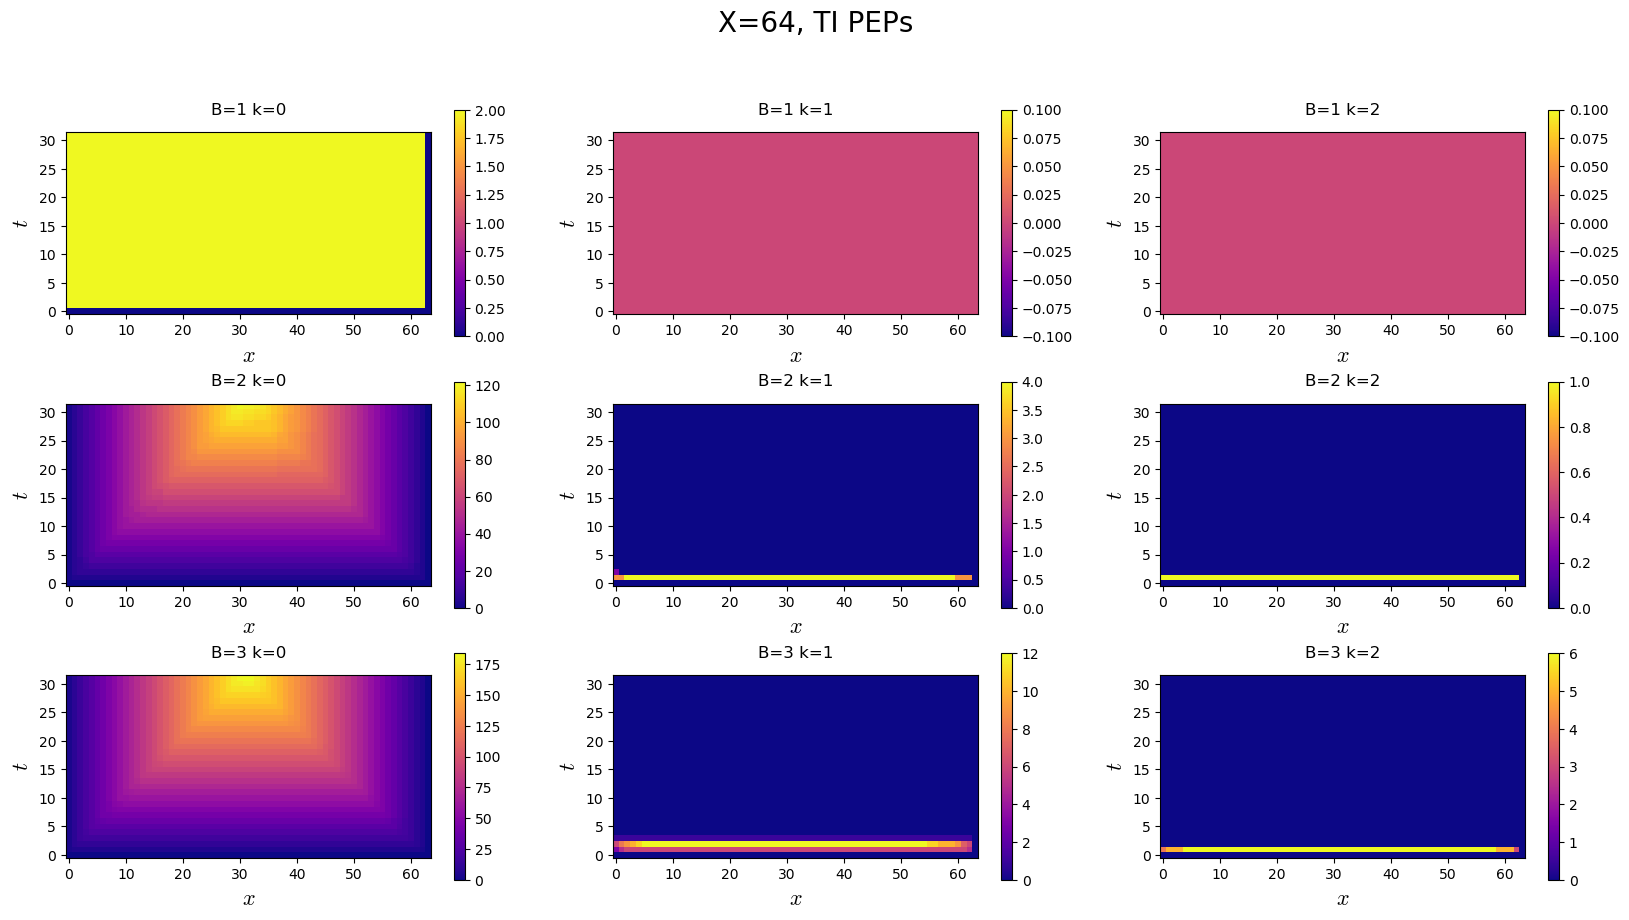

In [7]:
@load "./cache/221201_0vzs" result

fg, axs = subplots(3,3,figsize=(20,10))

B_list = 1:3
k_list = 0:2

cmap = PyPlot.get_cmap("plasma")


for (i,B) in enumerate(B_list)
    for (j,k) in enumerate(k_list)
        ax = axs[i,j]
        im = ax.matshow(result[i,j,:,:], cmap=cmap)
        ax.xaxis.set_ticks_position("bottom")
        ax.invert_yaxis()
        ax.set_xlabel(L"x",fontsize=16)
        ax.set_ylabel(L"t",fontsize=16)
        fg.colorbar(im,ax=ax)
        ax.set_title(string("B=", B, " k=", k))
    end
end

fg.suptitle("X=64, TI PEPs", fontsize=20)
fg.savefig("translational invariant PEPs.pdf")